In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

data = load_breast_cancer()
X, y = data.data, data.target

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [3]:
depths = range(1, 11)
mean_scores = []
std_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    
    print(f"Depth: {depth}, Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


Depth: 1, Accuracy: 0.8876 ± 0.0283
Depth: 2, Accuracy: 0.8859 ± 0.0264
Depth: 3, Accuracy: 0.9156 ± 0.0307
Depth: 4, Accuracy: 0.9262 ± 0.0311
Depth: 5, Accuracy: 0.9385 ± 0.0208
Depth: 6, Accuracy: 0.9367 ± 0.0204
Depth: 7, Accuracy: 0.9384 ± 0.0217
Depth: 8, Accuracy: 0.9384 ± 0.0217
Depth: 9, Accuracy: 0.9384 ± 0.0217
Depth: 10, Accuracy: 0.9384 ± 0.0217


In [4]:
best_depth = depths[np.argmax(mean_scores)]
print('Best Depth:', best_depth)

Best Depth: 5


In [5]:
final_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_depth,
    random_state=42
)

final_model.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

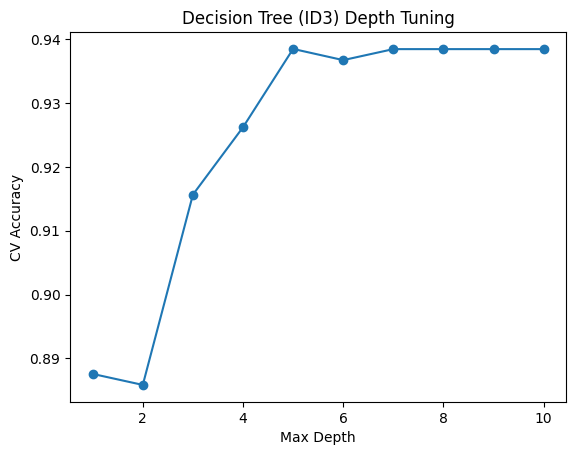

In [6]:
import matplotlib.pyplot as plt

plt.plot(depths, mean_scores, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("CV Accuracy")
plt.title("Decision Tree (ID3) Depth Tuning")
plt.show()